In [42]:
import tz_pypsa
import pandas as pd
import numpy as np
from tz_pypsa.model import Model
from google.cloud import bigquery
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tz_pypsa.constraints import (constr_max_annual_utilisation_generator, 
                                  constr_min_annual_utilisation_generator)

from itables import init_notebook_mode, show                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [34]:
# Extract actual data from data warehouse
from google.cloud import bigquery
client = bigquery.Client()

query = """
    SELECT *
    FROM `tz-data-dev.taiwan_lnd.power_breakdown`
"""
query_job = client.query(query)

# Convert the result to a pandas DataFrame
df = query_job.to_dataframe()
df['datetime_local'] = df['datetime'].dt.tz_convert('Asia/Taipei')

In [45]:
n=Model.load_csv_from_dir('./stock_models/Taiwan',
                          2024,
                          frequency='1h',
                          timesteps=8784,
                          backstop=True)

n.optimize.create_model()

constr_max_annual_utilisation_generator(n, carriers='Coal|LNG|Biomass|Geothermal')
constr_min_annual_utilisation_generator(n, carriers='Oil')

n.optimize.solve_model()

INFO:pypsa.io:Imported network Taiwan has buses, carriers, generators, loads, storage_units
Index(['TWN'], dtype='object', name='Bus')
Index(['TWN-CoGenCoal', 'TWN-CoGenBiomass', 'Backstop-TWN'], dtype='object', name='Generator')
INFO:linopy.model: Solve problem using Highs solver


['TWN-Coal', 'TWN-LNG', 'TWN-Geothermal', 'TWN-Biomass']
['TWN-Oil']


INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 4/4 [00:00<00:00,  9.27it/s]
INFO:linopy.io: Writing time: 2.67s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 158112 primals, 351365 duals
Objective: 1.35e+10
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-state_of_charge_set, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

# CHECKING RESULTS

In [46]:
# --- CHECKING BACKSTOP --- #

n.generators_t.p.filter(like='Backstop').sum()

Generator
Backstop-TWN    0.0
dtype: float64

In [47]:
# --- CHECKING ENERGY BALANCE --- #
fig = tz_pypsa.plotting.energy_balance(n, period='2024')
fig.update_layout(width=1000,height=500)
fig.show()

In [37]:
# --- CHECKING GENERATION PER TYPE --- #
loads = (
    n
    .loads_t
    .p_set
    .resample('YE')
    .sum()
    .div(1e6)
    .melt()
    .sort_values(by='Load')
    .reset_index(drop=True)
)

total_generation = (
    n
    .generators_t
    .p
    .resample('YE')
    .sum()
    .groupby([n.generators.bus, n.generators.carrier], axis=1)
    .sum()
    .div(1e6)
    .melt()
    .sort_values(by='bus')
)

# define order for x-axis
cat_order = total_generation.sort_values(by='bus').bus.unique().tolist()


fig = px.bar(
    total_generation, 
    x="bus", 
    y="value", 
    color = "carrier",
    category_orders={'bus' : cat_order},
    #barmode="group",
)

fig.add_scatter(
    x=loads.Load,
    y=loads.value,
    mode='markers',
    name='Load',
    marker=dict(
        size=7,
        color='red',
        symbol='circle',
    ),
)

fig.update_layout(
        yaxis_title= 'Generation (TWh)',
        xaxis_title='',
        # title='Installed capacity in ' + str(2023),
        width=1000,
        height=500,
        xaxis_tickangle=-45
    )

fig

In [38]:
# --- CHECK GENERATION MIX --- #

generation = (
    n.generators_t.p
     .resample('YE').sum()
     .groupby([n.generators.bus, n.generators.carrier], axis=1).sum()
     .melt()
     .rename(columns={'variable': 'carrier'})
)
generation.carrier.replace('', 'backstop', inplace=True)
generation.value = generation.value.div(1e6)
color_map = n.carriers.color.to_dict()
colors = [ color_map.get(c, "#999999") for c in generation.carrier ]

# 1×1 subplot of type “domain” (pie)
fig = make_subplots(
    rows=1, cols=1,
    specs=[[{'type':'domain'}]]
)

# add the pie into row=1,col=1
fig.add_trace(
    go.Pie(
        labels=generation.carrier,
        values=generation.value,
        marker=dict(colors=colors),
        textinfo='percent+label'
    ),
    row=1, col=1
)

fig.update_layout(
    title_text="Generation Mix in TWN (2024, TWh)",
    width=600,
    height=600
)

In [51]:
# --- CALIBRATION 1A: Yearly GENERATION 2024- actual data vs model --- #

gen_act = df.loc[df['datetime'].dt.year == 2024].copy()
gen_act['datetime'] = pd.to_datetime(gen_act['datetime'], format='%d-%m-%Y %H:%M:%S')
gen_act.set_index('datetime', inplace=True)
gen_act.sort_index(inplace=True)

# Select relevant columns and rename them
gen_act = gen_act[['production_nuclear',
                   'production_geothermal', 
                   'production_biomass', 
                   'production_coal',
                   'production_wind', 
                   'production_solar', 
                   'production_hydro',
                   'production_gas', 
                   'production_oil', 
                   'production_unknown',
]]

# Rename columns to match the model's output
gen_act.rename(columns={
    'production_nuclear': 'Nuclear',
    'production_geothermal': 'Geothermal',
    'production_biomass': 'Biomass',
    'production_coal': 'Coal',
    'production_wind': 'Wind',
    'production_solar': 'Solar',
    'production_hydro': 'Hydro',
    'production_gas': 'LNG',
    'production_oil': 'Oil',
    'production_unknown': 'CoGen'
}, inplace=True)

gen_act['CoGencoal'] = gen_act['CoGen']*0.76
gen_act['CoGenbiomass'] = gen_act['CoGen']*0.24
gen_act.drop(columns=['CoGen'], inplace=True)

# Pypsa results
gen_pypsa = (
    n
    .generators_t
    .p
    .groupby(by=[n.generators.carrier],axis=1)
    .sum().sum()
    .to_frame().reset_index().rename(columns={'carrier':'Fuel', 0:'gen_pypsa'})
)

gen_act = gen_act.sum().to_frame().reset_index().rename(columns={'index':'Fuel', 0:'gen_act'})

# Combine both
gen = gen_pypsa.merge(gen_act,how='outer',on='Fuel')

fig = px.bar(
    gen, 
    x="Fuel",
    y=["gen_pypsa", "gen_act"],
    barmode="group",
    labels={"value": "Generation (MWh)", 
            "variable": "Generation"},
    title="Generation Comparison in TWN (2024)"
)

fig.update_layout(
    width=1000,
    height=600,
    xaxis_title='Fuel Type',
    yaxis_title='Generation (MWh)',
    legend=dict(title='', x=0.8, y=1)
)

fig.show()

In [40]:
pypsa_ph = n.storage_units_t.p[['TWN-PumpedHydro']]

gen_act = df.loc[df['datetime'].dt.year == 2024].copy()
gen_act['datetime'] = pd.to_datetime(gen_act['datetime'], format='%d-%m-%Y %H:%M:%S')
gen_act.set_index('datetime', inplace=True)
gen_act.sort_index(inplace=True)
act_ph = gen_act[['production_hydro discharge']]

pypsa_ph.index = pypsa_ph.index.tz_localize(None)
act_ph.index = act_ph.index.tz_localize(None)

combined_ph = pd.merge(pypsa_ph, act_ph, left_index=True, right_index=True)

px.line(
    combined_ph,
    x=combined_ph.index,
    y=combined_ph.columns,
    labels={'value': 'Generation (MWh)', 'variable': 'Generation'},
    title='Pumped Hydro Generation in TWN (2024)',
    width=1000,
)

In [52]:
# --- CALIBRATION 1B: GENERATION 2024 COMPARISON (%)- Official data vs model --- #

# (PyPSA – Official) / Official * 100
percent_diff = (gen['gen_pypsa'] - gen['gen_act']) / gen['gen_act'] * 100

fig = go.Figure()

fig.add_trace(go.Bar(
    x=gen['Fuel'],
    y=percent_diff,
    name='PyPSA vs Official %Δ',
))

# Add ±10% reference lines
fig.add_hline(
    y=10,
    line_dash='dash',
    line_color='green',
    annotation_text='+10%',
    annotation_position='top left'
)
fig.add_hline(
    y=-10,
    line_dash='dash',
    line_color='red',
    annotation_text='-10%',
    annotation_position='bottom left'
)

# Final layout tweaks
fig.update_layout(
    title_text='2024 Generation Difference as % of Official',
    xaxis_title='Fuel',
    yaxis_title='Difference (%)',
    width=800,
    height=600,
    showlegend=False
)

fig.show()

# Annotate the % of generation

In [ ]:
# --- CALIBRATION 1C: YEARLY CAPACITY FACTOR 2024 - Official data vs model --- #

# Extract CF results
cf_pypsa = (n.statistics.capacity_factor(groupby=['bus','carrier']).reset_index().rename(columns={'carrier':'Fuel', 0:'cf_pypsa'})
)

# Official pnom results
pnom_act = (
    n
    .generators
    .p_nom_opt
    .groupby(by=[n.generators.carrier])
    .sum()
    .to_frame().reset_index().rename(columns={'carrier':'Fuel', 0:'cf_pypsa'})
)

cf_act = gen_act.merge(pnom_act,how='outer',on='Fuel')
cf_act['cf_act'] = cf_act['gen_act'].div(cf_act['p_nom_opt'] * 8760)
cf_comparison = cf_act.merge(cf_pypsa.loc[(cf_pypsa['component'] == 'Generator')],
                      how='outer',on='Fuel')

fig = px.bar(
    cf_comparison, 
    x="Fuel",
    y=["cf_pypsa", "cf_act"],
    barmode="group",
    labels={"value": "Capacity Factor (%)", 
            "variable": "Capaicity Factor"},
    title="Capacity Factor Comparison in TWN (2024)"
)

fig.update_layout(
    width=1000,
    height=600,
    xaxis_title='Fuel Type',
    yaxis_title='capacity factor (%)',
    legend=dict(title='', x=0.8, y=1)
)

fig.show()


In [ ]:
# --- CALIBRATION 2: DISPATCH MONTHLY 2024 - (actual monthly total vs model per type) --- #

gen_act = df.loc[df['datetime'].dt.year == 2024].copy()
gen_act['datetime'] = pd.to_datetime(gen_act['datetime'], format='%d-%m-%Y %H:%M:%S')
gen_act.set_index('datetime', inplace=True)
gen_act.sort_index(inplace=True)

# Select relevant columns and rename them
gen_act = gen_act[['production_nuclear',
                   'production_geothermal', 
                   'production_biomass', 
                   'production_coal',
                   'production_wind', 
                   'production_solar', 
                   'production_hydro',
                   'production_gas', 
                   'production_oil', 
                   'production_unknown',
                   'production_hydro discharge']]

# Rename columns to match the model's output
gen_act.rename(columns={
    'production_nuclear': 'Nuclear',
    'production_geothermal': 'Geothermal',
    'production_biomass': 'Biomass',
    'production_coal': 'Coal',
    'production_wind': 'Wind',
    'production_solar': 'Solar',
    'production_hydro': 'Hydro',
    'production_gas': 'LNG',
    'production_oil': 'Oil',
    'production_unknown': 'Other',
    'production_hydro discharge': 'Hydro discharge'
}, inplace=True)

gen_act_monthly = gen_act.resample('m').sum().reset_index()
gen_act_monthly['month'] = gen_act_monthly.datetime.dt.month

# Pypsa results
gen_pypsa_monthly = (
    n
    .generators_t
    .p
    .groupby(n.generators.carrier, axis=1)
    .sum()
    .resample('m')
    .sum()
    .reset_index()
    .drop(columns='backstop')
    .copy()
)

gen_pypsa_monthly['month'] = gen_pypsa_monthly.snapshot.dt.month

In [ ]:
def plot_monthly_comparison_with_tolerance(
    actual_df: pd.DataFrame,
    pypsa_df: pd.DataFrame,
    month_col: str,
    tech_col: str,
    tolerance: float = 0.05,
    title: str = None
) -> go.Figure:
    """
    Merge actual_df and pypsa_df on month_col, adding _actual/_pypsa suffixes
    to tech_col if they collide, then plot grouped bars with ±tolerance.
    """
    # Sanity check
    for df, name in [(actual_df, "actual_df"), (pypsa_df, "pypsa_df")]:
        if tech_col not in df.columns:
            raise KeyError(f"Column '{tech_col}' not found in {name}. "
                           f"Available: {df.columns.tolist()}")

    # Merge, letting pandas suffix your tech_col
    merged = actual_df[[month_col, tech_col]].merge(
        pypsa_df[[month_col, tech_col]],
        on=month_col,
        how='inner',
        suffixes=('_actual', '_pypsa')
    )

    # Build the actual column names
    actual_col = f"{tech_col}_actual"
    model_col  = f"{tech_col}_pypsa"

    # Compute error bars
    merged['err'] = merged[actual_col].abs() * tolerance

    # Plot
    fig = go.Figure([
        go.Bar(
            x=merged[month_col],
            y=merged[actual_col],
            name=f"{tech_col} (Actual)",
            error_y=dict(
                type='data',
                array=merged['err'],
                arrayminus=merged['err']
            )
        ),
        go.Bar(
            x=merged[month_col],
            y=merged[model_col],
            name=f"{tech_col} (Modelled)"
        )
    ])

    fig.update_layout(
        barmode='group',
        title=title or f"Monthly {tech_col}: Actual vs Modelled (±{tolerance*100:.0f}% band)",
        xaxis_title=month_col,
        yaxis_title=f"Value ({tech_col})",
        legend=dict(x=0.02, y=0.98)
    )

    return fig

In [ ]:
# List all of your tech names (the prefixes common to _actual and _pypsa cols)
techs = ['Coal', 'LNG', 'Oil', 'Nuclear','Hydro', 'Solar', 'Wind', 'Geothermal', 'Biomass']  # ← adjust to your actual tech list

# Prepare a dict to hold the resulting figures
figs = {}

for tech in techs:
    actual_col = f"{tech}_actual"
    model_col  = f"{tech}_pypsa"
    title      = f"{tech}: Actual vs Modelled"
    
    try:
        fig = plot_monthly_comparison_with_tolerance(
            actual_df=gen_act_monthly,
            pypsa_df=gen_pypsa_monthly,
            month_col='month',
            tech_col=tech,
            tolerance=0.15,
            title=title
        )
        figs[tech] = fig
        fig.show()
    except KeyError as e:
        print(f"⚠️ Skipping {tech!r}: {e}")

In [ ]:
# --- Calibration 3A: Monthly comparison of max CF 2024 --- #

# Monthly official
cf_ofc_hourly = pd.DataFrame()
cf_ofc_hourly['Coal'] = gen_act['Coal'] / pnom_act[pnom_act['Fuel'] == 'Coal'].p_nom_opt.values
cf_ofc_hourly['LNG'] = gen_act['LNG'] / pnom_act[pnom_act['Fuel'] == 'LNG'].p_nom_opt.values
cf_ofc_hourly['Oil'] = gen_act['Oil'] / pnom_act[pnom_act['Fuel'] == 'Oil'].p_nom_opt.values
cf_ofc_hourly['Nuclear'] = gen_act['Nuclear'] / pnom_act[pnom_act['Fuel'] == 'Nuclear'].p_nom_opt.values
cf_ofc_hourly['Solar'] = gen_act['Solar'] / pnom_act[pnom_act['Fuel'] == 'Solar'].p_nom_opt.values
cf_ofc_hourly['Wind'] = gen_act['Wind'] / pnom_act[pnom_act['Fuel'] == 'Wind'].p_nom_opt.values
cf_ofc_hourly['Hydro'] = gen_act['Hydro'] / pnom_act[pnom_act['Fuel'] == 'Hydro'].p_nom_opt.values
cf_ofc_hourly['Wind'] = gen_act['Wind'] / pnom_act[pnom_act['Fuel'] == 'Wind'].p_nom_opt.values
cf_ofc_hourly['Geothermal'] = gen_act['Geothermal'] / pnom_act[pnom_act['Fuel'] == 'Geothermal'].p_nom_opt.values
cf_ofc_hourly['Biomass'] = gen_act['Biomass'] / pnom_act[pnom_act['Fuel'] == 'Biomass'].p_nom_opt.values

cf_ofc_monthly = (cf_ofc_hourly.resample('M').max())

# Monthly model
gen_pypsa = (
    n
    .generators_t
    .p
    .groupby(by=[n.generators.carrier],axis=1)
    .sum()
    .rename(columns={'index':'timestamp'})
)

cf_pypsa_hourly = pd.DataFrame()
cf_pypsa_hourly['Coal'] = gen_pypsa['Coal'] / pnom_act[pnom_act['Fuel'] == 'Coal'].p_nom_opt.values
cf_pypsa_hourly['LNG'] = gen_pypsa['LNG'] / pnom_act[pnom_act['Fuel'] == 'LNG'].p_nom_opt.values
cf_pypsa_hourly['Oil'] = gen_pypsa['Oil'] / pnom_act[pnom_act['Fuel'] == 'Oil'].p_nom_opt.values
cf_pypsa_hourly['Nuclear'] = gen_pypsa['Nuclear'] / pnom_act[pnom_act['Fuel'] == 'Nuclear'].p_nom_opt.values
cf_pypsa_hourly['Solar'] = gen_pypsa['Solar'] / pnom_act[pnom_act['Fuel'] == 'Solar'].p_nom_opt.values
cf_pypsa_hourly['Wind'] = gen_pypsa['Wind'] / pnom_act[pnom_act['Fuel'] == 'Wind'].p_nom_opt.values
cf_pypsa_hourly['Hydro'] = gen_pypsa['Hydro'] / pnom_act[pnom_act['Fuel'] == 'Hydro'].p_nom_opt.values
cf_pypsa_hourly['Geothermal'] = gen_pypsa['Geothermal'] / pnom_act[pnom_act['Fuel'] == 'Geothermal'].p_nom_opt.values
cf_pypsa_hourly['Biomass'] = gen_pypsa['Biomass'] / pnom_act[pnom_act['Fuel'] == 'Biomass'].p_nom_opt.values


cf_pypsa_monthly = cf_pypsa_hourly.resample('M').max()

fig = make_subplots(rows=9, cols=1,shared_xaxes=False, subplot_titles = ['Coal','LNG', 'Oil', 'Nuclear', 'Solar', 'Wind', 'Hydro', 'Geothermal', 'Biomass'])
month = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# subplot 1 - Coal generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Coal'], name="reference",legendgroup="reference",marker=dict(color='blue')),1,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Coal'], name="model",legendgroup="model",marker=dict(color='red')),1,1)

# subplot 2 - LNG generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['LNG'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),2,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['LNG'],legendgroup="model",showlegend=False,marker=dict(color='red')),2,1)

# subplot 3 - Oil generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Oil'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),3,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Oil'],legendgroup="model",showlegend=False,marker=dict(color='red')),3,1)

# subplot 4 - Nuclear generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Nuclear'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),4,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Nuclear'],legendgroup="model",showlegend=False,marker=dict(color='red')),4,1)

# subplot 5 - Solar generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Solar'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),5,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Solar'],legendgroup="model",showlegend=False,marker=dict(color='red')),5,1)

# subplot 6 - Wind generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Wind'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),6,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Wind'],legendgroup="model",showlegend=False,marker=dict(color='red')),6,1)

# subplot 7 - hydro generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Hydro'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),7,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Hydro'],legendgroup="model",showlegend=False,marker=dict(color='red')),7,1)

# subplot 8 - geothermal generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Geothermal'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),8,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Geothermal'],legendgroup="model",showlegend=False,marker=dict(color='red')),8,1)

# subplot 9 - biomass generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Biomass'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),9,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Biomass'],legendgroup="model",showlegend=False,marker=dict(color='red')),9,1)


fig.update_layout(title_text="2024 MAX CF COMPARISON",
                  width=800,height=1000)

fig.show()



In [ ]:
# --- Calibration 3B: Monthly comparison of mean CF 2024 --- #

# Monthly official
cf_ofc_hourly = pd.DataFrame()
cf_ofc_hourly['Coal'] = gen_act['Coal'] / pnom_act[pnom_act['Fuel'] == 'Coal'].p_nom_opt.values
cf_ofc_hourly['LNG'] = gen_act['LNG'] / pnom_act[pnom_act['Fuel'] == 'LNG'].p_nom_opt.values
cf_ofc_hourly['Oil'] = gen_act['Oil'] / pnom_act[pnom_act['Fuel'] == 'Oil'].p_nom_opt.values
cf_ofc_hourly['Nuclear'] = gen_act['Nuclear'] / pnom_act[pnom_act['Fuel'] == 'Nuclear'].p_nom_opt.values
cf_ofc_hourly['Solar'] = gen_act['Solar'] / pnom_act[pnom_act['Fuel'] == 'Solar'].p_nom_opt.values
cf_ofc_hourly['Wind'] = gen_act['Wind'] / pnom_act[pnom_act['Fuel'] == 'Wind'].p_nom_opt.values
cf_ofc_hourly['Hydro'] = gen_act['Hydro'] / pnom_act[pnom_act['Fuel'] == 'Hydro'].p_nom_opt.values
cf_ofc_hourly['Wind'] = gen_act['Wind'] / pnom_act[pnom_act['Fuel'] == 'Wind'].p_nom_opt.values
cf_ofc_hourly['Geothermal'] = gen_act['Geothermal'] / pnom_act[pnom_act['Fuel'] == 'Geothermal'].p_nom_opt.values
cf_ofc_hourly['Biomass'] = gen_act['Biomass'] / pnom_act[pnom_act['Fuel'] == 'Biomass'].p_nom_opt.values

cf_ofc_monthly = (cf_ofc_hourly.resample('M').mean())

# Monthly model
gen_pypsa = (
    n
    .generators_t
    .p
    .groupby(by=[n.generators.carrier],axis=1)
    .sum()
    .rename(columns={'index':'timestamp'})
)

cf_pypsa_hourly = pd.DataFrame()
cf_pypsa_hourly['Coal'] = gen_pypsa['Coal'] / pnom_act[pnom_act['Fuel'] == 'Coal'].p_nom_opt.values
cf_pypsa_hourly['LNG'] = gen_pypsa['LNG'] / pnom_act[pnom_act['Fuel'] == 'LNG'].p_nom_opt.values
cf_pypsa_hourly['Oil'] = gen_pypsa['Oil'] / pnom_act[pnom_act['Fuel'] == 'Oil'].p_nom_opt.values
cf_pypsa_hourly['Nuclear'] = gen_pypsa['Nuclear'] / pnom_act[pnom_act['Fuel'] == 'Nuclear'].p_nom_opt.values
cf_pypsa_hourly['Solar'] = gen_pypsa['Solar'] / pnom_act[pnom_act['Fuel'] == 'Solar'].p_nom_opt.values
cf_pypsa_hourly['Wind'] = gen_pypsa['Wind'] / pnom_act[pnom_act['Fuel'] == 'Wind'].p_nom_opt.values
cf_pypsa_hourly['Hydro'] = gen_pypsa['Hydro'] / pnom_act[pnom_act['Fuel'] == 'Hydro'].p_nom_opt.values
cf_pypsa_hourly['Geothermal'] = gen_pypsa['Geothermal'] / pnom_act[pnom_act['Fuel'] == 'Geothermal'].p_nom_opt.values
cf_pypsa_hourly['Biomass'] = gen_pypsa['Biomass'] / pnom_act[pnom_act['Fuel'] == 'Biomass'].p_nom_opt.values


cf_pypsa_monthly = cf_pypsa_hourly.resample('M').mean()

fig = make_subplots(rows=9, cols=1,shared_xaxes=False, subplot_titles = ['Coal','LNG', 'Oil', 'Nuclear', 'Solar', 'Wind', 'Hydro', 'Geothermal', 'Biomass'])
month = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# subplot 1 - Coal generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Coal'], name="reference",legendgroup="reference",marker=dict(color='blue')),1,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Coal'], name="model",legendgroup="model",marker=dict(color='red')),1,1)

# subplot 2 - LNG generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['LNG'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),2,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['LNG'],legendgroup="model",showlegend=False,marker=dict(color='red')),2,1)

# subplot 3 - Oil generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Oil'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),3,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Oil'],legendgroup="model",showlegend=False,marker=dict(color='red')),3,1)

# subplot 4 - Nuclear generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Nuclear'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),4,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Nuclear'],legendgroup="model",showlegend=False,marker=dict(color='red')),4,1)

# subplot 5 - Solar generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Solar'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),5,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Solar'],legendgroup="model",showlegend=False,marker=dict(color='red')),5,1)

# subplot 6 - Wind generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Wind'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),6,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Wind'],legendgroup="model",showlegend=False,marker=dict(color='red')),6,1)

# subplot 7 - hydro generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Hydro'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),7,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Hydro'],legendgroup="model",showlegend=False,marker=dict(color='red')),7,1)

# subplot 8 - geothermal generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Geothermal'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),8,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Geothermal'],legendgroup="model",showlegend=False,marker=dict(color='red')),8,1)

# subplot 9 - biomass generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Biomass'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),9,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Biomass'],legendgroup="model",showlegend=False,marker=dict(color='red')),9,1)


fig.update_layout(title_text="2024 MEAN CF COMPARISON",
                  width=800,height=1000)

fig.show()

In [ ]:
# --- Calibration 3C: Monthly comparison of min CF 2024 --- #

# Monthly official
cf_ofc_hourly = pd.DataFrame()
cf_ofc_hourly['Coal'] = gen_act['Coal'] / pnom_act[pnom_act['Fuel'] == 'Coal'].p_nom_opt.values
cf_ofc_hourly['LNG'] = gen_act['LNG'] / pnom_act[pnom_act['Fuel'] == 'LNG'].p_nom_opt.values
cf_ofc_hourly['Oil'] = gen_act['Oil'] / pnom_act[pnom_act['Fuel'] == 'Oil'].p_nom_opt.values
cf_ofc_hourly['Nuclear'] = gen_act['Nuclear'] / pnom_act[pnom_act['Fuel'] == 'Nuclear'].p_nom_opt.values
cf_ofc_hourly['Solar'] = gen_act['Solar'] / pnom_act[pnom_act['Fuel'] == 'Solar'].p_nom_opt.values
cf_ofc_hourly['Wind'] = gen_act['Wind'] / pnom_act[pnom_act['Fuel'] == 'Wind'].p_nom_opt.values
cf_ofc_hourly['Hydro'] = gen_act['Hydro'] / pnom_act[pnom_act['Fuel'] == 'Hydro'].p_nom_opt.values
cf_ofc_hourly['Wind'] = gen_act['Wind'] / pnom_act[pnom_act['Fuel'] == 'Wind'].p_nom_opt.values
cf_ofc_hourly['Geothermal'] = gen_act['Geothermal'] / pnom_act[pnom_act['Fuel'] == 'Geothermal'].p_nom_opt.values
cf_ofc_hourly['Biomass'] = gen_act['Biomass'] / pnom_act[pnom_act['Fuel'] == 'Biomass'].p_nom_opt.values

cf_ofc_monthly = (cf_ofc_hourly.resample('M').min())

# Monthly model
gen_pypsa = (
    n
    .generators_t
    .p
    .droplevel(0)
    .groupby(by=[n.generators.carrier],axis=1)
    .sum()
    .rename(columns={'index':'timestamp'})
)

cf_pypsa_hourly = pd.DataFrame()
cf_pypsa_hourly['Coal'] = gen_pypsa['Coal'] / pnom_act[pnom_act['Fuel'] == 'Coal'].p_nom_opt.values
cf_pypsa_hourly['LNG'] = gen_pypsa['LNG'] / pnom_act[pnom_act['Fuel'] == 'LNG'].p_nom_opt.values
cf_pypsa_hourly['Oil'] = gen_pypsa['Oil'] / pnom_act[pnom_act['Fuel'] == 'Oil'].p_nom_opt.values
cf_pypsa_hourly['Nuclear'] = gen_pypsa['Nuclear'] / pnom_act[pnom_act['Fuel'] == 'Nuclear'].p_nom_opt.values
cf_pypsa_hourly['Solar'] = gen_pypsa['Solar'] / pnom_act[pnom_act['Fuel'] == 'Solar'].p_nom_opt.values
cf_pypsa_hourly['Wind'] = gen_pypsa['Wind'] / pnom_act[pnom_act['Fuel'] == 'Wind'].p_nom_opt.values
cf_pypsa_hourly['Hydro'] = gen_pypsa['Hydro'] / pnom_act[pnom_act['Fuel'] == 'Hydro'].p_nom_opt.values
cf_pypsa_hourly['Geothermal'] = gen_pypsa['Geothermal'] / pnom_act[pnom_act['Fuel'] == 'Geothermal'].p_nom_opt.values
cf_pypsa_hourly['Biomass'] = gen_pypsa['Biomass'] / pnom_act[pnom_act['Fuel'] == 'Biomass'].p_nom_opt.values


cf_pypsa_monthly = cf_pypsa_hourly.resample('M').min()

fig = make_subplots(rows=9, cols=1,shared_xaxes=False, subplot_titles = ['Coal','LNG', 'Oil', 'Nuclear', 'Solar', 'Wind', 'Hydro', 'Geothermal', 'Biomass'])
month = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# subplot 1 - Coal generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Coal'], name="reference",legendgroup="reference",marker=dict(color='blue')),1,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Coal'], name="model",legendgroup="model",marker=dict(color='red')),1,1)

# subplot 2 - LNG generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['LNG'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),2,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['LNG'],legendgroup="model",showlegend=False,marker=dict(color='red')),2,1)

# subplot 3 - Oil generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Oil'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),3,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Oil'],legendgroup="model",showlegend=False,marker=dict(color='red')),3,1)

# subplot 4 - Nuclear generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Nuclear'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),4,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Nuclear'],legendgroup="model",showlegend=False,marker=dict(color='red')),4,1)

# subplot 5 - Solar generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Solar'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),5,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Solar'],legendgroup="model",showlegend=False,marker=dict(color='red')),5,1)

# subplot 6 - Wind generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Wind'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),6,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Wind'],legendgroup="model",showlegend=False,marker=dict(color='red')),6,1)

# subplot 7 - hydro generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Hydro'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),7,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Hydro'],legendgroup="model",showlegend=False,marker=dict(color='red')),7,1)

# subplot 8 - geothermal generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Geothermal'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),8,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Geothermal'],legendgroup="model",showlegend=False,marker=dict(color='red')),8,1)

# subplot 9 - biomass generation comparison
fig.add_trace(go.Bar(x=month, y=cf_ofc_monthly['Biomass'],legendgroup="reference",showlegend=False,marker=dict(color='blue')),9,1)
fig.add_trace(go.Bar(x=month, y=cf_pypsa_monthly['Biomass'],legendgroup="model",showlegend=False,marker=dict(color='red')),9,1)


fig.update_layout(title_text="2024 MIN CF COMPARISON",
                  width=800,height=1000)

fig.show()

In [ ]:
# --- CALIBRATION 4: DISPATCH 2024 - model run --- #
# Note: this is the daily aggregated dispatch and demand profile for 2024

generation = (
    n
    .generators_t
    .p
    .groupby(n.generators.carrier, axis=1)
    .sum()
    .resample('d')
    .sum()
    .reset_index()
    .drop(columns='backstop')
    .copy()
)

# get load
load = (
    n
    .loads_t
    .p
    .sum(axis=1)
    .resample('d')
    .sum()
    .reset_index()
)

# Create figure
fig = go.Figure()

# add traces
for generator in generation.columns:

    if generator != 'snapshot':
        fig.add_trace(
            go.Scatter(
                x=list(generation.snapshot),
                y=list(generation[generator]),
                mode='lines',
                stackgroup='one',
                name=generator,
                line=dict(color=n.carriers.color.to_dict()[generator]),
            )
        )

# add load
fig.add_trace(
        go.Scatter(
        x=list(load.snapshot),
        y=list(load[0]),
        mode='lines',
        #stackgroup='one',
        name='Load',
        line=dict(color='black', width=3),
    )
)

# Add range slider
fig.update_layout(
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=5,
                        label="5D",
                        step="day",
                        stepmode="backward"),
                dict(count=1,
                        label="1M",
                        step="month",
                        stepmode="backward"),
                dict(count=3,
                        label="3M",
                        step="month",
                        stepmode="backward"),
                dict(count=1,
                        label="1Y",
                        step="year",
                        stepmode="backward"),
                # dict(step="all")
            ])
        ),
        rangeslider=dict(
            visible=True
        ),
        type="date",
    ),
    # yaxis_range=(0, (df.drop('timestep',axis=1).sum(axis=1).max() / 1e3)*1.05 ),
    yaxis_title='Generation [MWh]',
    xaxis_title='Time (Day)',
    title='Daily Generation',
    width=1200,
    height=500,
)

fig.show()


Preprocessing

In [27]:
# --- Preprocessing (1): Pumped Hydro Daily Profile Creation --- #
gen_act = df.copy()
gen_act['datetime_local'] = pd.to_datetime(gen_act['datetime_local'], format='%d-%m-%Y %H:%M:%S')
gen_act.set_index('datetime_local', inplace=True)
gen_act.sort_index(inplace=True)

<Axes: xlabel='datetime_local'>

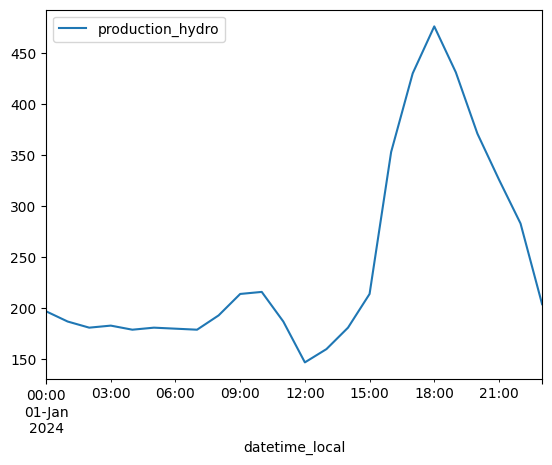

In [32]:
ph = gen_act[['production_hydro']].copy()
ph.loc['2024-01-01'].plot()

In [ ]:
# # --- Preprocessing (1): Pumped Hydro Daily Profile Creation --- #
# gen_act = df.copy()
# gen_act['datetime'] = pd.to_datetime(gen_act['datetime'], format='%d-%m-%Y %H:%M:%S')
# gen_act.set_index('datetime', inplace=True)
# gen_act.sort_index(inplace=True)

# ph = gen_act[['production_hydro discharge']].copy()
# ph['hour'] = ph.index.hour
# ph['day'] = ph.index.day

# # Filter for specific years
# years = [2024]
# ph = ph[
#     ph.index.year.isin(years)
# ]

# ph = ph.loc['2024-01-01':'2024-3-24']

# ph_wide = ph.pivot_table(
#     index='hour',
#     columns='day',
#     values='production_hydro discharge'
# )

# ph_wide['average'] = ph_wide.mean(axis=1)


# daily_profile = ph_wide['average'].copy()

# # --- Build a yearly SoC profile ---
# soc_daily = (daily_profile*-1).cumsum()

# soc_daily -= soc_daily.min()

# # --- Expand this daily pattern across the year ---
# snapshots = pd.date_range("2024-01-01", "2024-12-31 23:00", freq="H")

# daily_soc_pattern = pd.Series(index=snapshots, data=[soc_daily[h] for h in snapshots.hour])

# daily_soc_pattern = daily_soc_pattern.to_frame().reset_index(drop=True).rename(columns={0:'TWN-PumpedHydro'})

# daily_soc_pattern.to_csv('storage_units-state_of_charge_set.csv', index=True)

# --- Preprocessing (2): LNG Max Utilisation Rate Calculation --- #
# gen_act_lng = df[['datetime', 'production_gas']].copy()
# gen_act_lng['datetime'] = pd.to_datetime(gen_act_lng['datetime'], format='%d-%m-%Y %H:%M:%S')
# gen_act_lng['year'] = gen_act_lng['datetime'].dt.year
# gen_act_lng.sort_values(by='datetime', inplace=True, ignore_index=True)

# years = [2018, 2020, 2021, 2022, 2024]
# gen_act_lng = gen_act_lng[
#     gen_act_lng['year'].isin(years)
# ]

# lng_capacity = pd.read_csv('lng_installed_capacity_hist.csv')
# lng_gen_merged = pd.merge(
#     gen_act_lng, lng_capacity, on='year', how='left'
# )
# lng_gen_merged['CF'] = lng_gen_merged['production_gas'] / lng_gen_merged['Capacity_MW']
# lng_gen_merged.groupby('year')['CF'].mean().mean()

# px.line(
#     lng_gen_merged, 
#     x='datetime', 
#     y='CF', 
#     color='year',
#     title='lng Capacity Factor in Taiwan',
#     labels={'CF': 'Capacity Factor', 'datetime': 'Date'},
#     width=1000,
#     height=500
# ).update_traces(mode='lines+markers')

# lng_gen_merged.groupby('year')['CF'].max().mean()


# --- Preprocessing (3): Nuclear Max Utilisation Rate Calculation --- #
# gen_act_nuclear = df[['datetime', 'production_nuclear']].copy()
# gen_act_nuclear['datetime'] = pd.to_datetime(gen_act_nuclear['datetime'], format='%d-%m-%Y %H:%M:%S')
# gen_act_nuclear['year'] = gen_act_nuclear['datetime'].dt.year
# gen_act_nuclear.sort_values(by='datetime', inplace=True, ignore_index=True)

# years = [2024]
# gen_act_nuclear = gen_act_nuclear[
#     gen_act_nuclear['year'].isin(years)
# ]

# px.line(
#     gen_act_nuclear, 
#     x='datetime', 
#     y='production_nuclear', 
#     width=1000,
#     height=500
# ).update_traces(mode='lines+markers')


# --- Preprocessing (4): Coal Max Utilisation Rate Calculation --- #
# gen_act_coal = df[['datetime', 'production_coal']].copy()
# gen_act_coal['datetime'] = pd.to_datetime(gen_act_coal['datetime'], format='%d-%m-%Y %H:%M:%S')
# gen_act_coal['year'] = gen_act_coal['datetime'].dt.year
# gen_act_coal.sort_values(by='datetime', inplace=True, ignore_index=True)

# years = [2019, 2020, 2021, 2022, 2024]
# gen_act_coal = gen_act_coal[
#     gen_act_coal['year'].isin(years)
# ]

# coal_capacity = pd.read_csv('coal_installed_capacity_hist.csv')
# coal_gen_merged = pd.merge(
#     gen_act_coal, coal_capacity, on='year', how='left'
# )
# coal_gen_merged['CF'] = coal_gen_merged['production_coal'] / coal_gen_merged['Capacity_MW']
# coal_gen_merged.groupby('year')['CF'].mean().mean()

# px.line(
#     coal_gen_merged, 
#     x='datetime', 
#     y='CF', 
#     color='year',
#     title='Coal Capacity Factor in Taiwan',
#     labels={'CF': 'Capacity Factor', 'datetime': 'Date'},
#     width=1000,
#     height=500
# ).update_traces(mode='lines+markers')

# --- Preprocessing (5): Oil Min Utilisation Rate Calculation --- #
# gen_act_oil = df[['datetime', 'production_oil']].copy()
# gen_act_oil['datetime'] = pd.to_datetime(gen_act_oil['datetime'], format='%d-%m-%Y %H:%M:%S')
# gen_act_oil['year'] = gen_act_oil['datetime'].dt.year
# gen_act_oil.sort_values(by='datetime', inplace=True, ignore_index=True)

# years = [2019, 2020, 2021, 2022, 2024]
# gen_act_oil = gen_act_oil[
#     gen_act_oil['year'].isin(years)
# ]

# oil_capacity = pd.read_csv('oil_installed_capacity_hist.csv')
# oil_gen_merged = pd.merge(
#     gen_act_oil, oil_capacity, on='year', how='left'
# )
# oil_gen_merged['CF'] = oil_gen_merged['production_oil'] / oil_gen_merged['Capacity_MW']
# oil_gen_merged.groupby('year')['CF'].mean().mean()

# px.line(
#     oil_gen_merged, 
#     x='datetime', 
#     y='CF', 
#     color='year',
#     title='Oil Capacity Factor in Taiwan',
#     labels={'CF': 'Capacity Factor', 'datetime': 'Date'},
#     width=1000,
#     height=500
# ).update_traces(mode='lines+markers')

# --- Preprocessing (6): Biomass Max Utilisation Rate Calculation --- #
# gen_act_biomass = df[['datetime', 'production_biomass']].copy()
# gen_act_biomass['datetime'] = pd.to_datetime(gen_act_biomass['datetime'], format='%d-%m-%Y %H:%M:%S')
# gen_act_biomass['year'] = gen_act_biomass['datetime'].dt.year
# gen_act_biomass.sort_values(by='datetime', inplace=True, ignore_index=True)

# years = [2024]
# gen_act_biomass = gen_act_biomass[
#     gen_act_biomass['year'].isin(years)
# ]

# gen_act_biomass['CF'] = gen_act_biomass['production_biomass'] / 38 # Installed capacity for biomass in 2024

# px.line(
#     gen_act_biomass,
#     x='datetime',
#     y='production_biomass',
#     title='Biomass Generation in Taiwan',
#     labels={'production_biomass': 'Biomass Generation (MWh)', 'datetime': 'Date'},
#     width=1000,
#     height=500
# ).show()

# --- Preprocessing (7): Geothermal Max Utilisation Rate Calculation --- #
# gen_act_geothermal = df[['datetime', 'production_geothermal']].copy()
# gen_act_geothermal['datetime'] = pd.to_datetime(gen_act_geothermal['datetime'], format='%d-%m-%Y %H:%M:%S')
# gen_act_geothermal['year'] = gen_act_geothermal['datetime'].dt.year
# gen_act_geothermal.sort_values(by='datetime', inplace=True, ignore_index=True)

# years = [2024]
# gen_act_geothermal = gen_act_geothermal[
#     gen_act_geothermal['year'].isin(years)
# ]

# geothermal_capacity = pd.read_csv('geothermal_installed_capacity_hist.csv')
# geothermal_gen_merged = pd.merge(
#     gen_act_geothermal, geothermal_capacity, on='year', how='left'
# )
# geothermal_gen_merged['CF'] = geothermal_gen_merged['production_geothermal'] / geothermal_gen_merged['installed_capacity_mw']
# geothermal_gen_merged.groupby('year')['CF'].mean().mean()

# px.line(
#     geothermal_gen_merged, 
#     x='datetime', 
#     y='CF', 
#     color='year',
#     title='Geothermal Capacity Factor in Taiwan',
#     labels={'CF': 'Capacity Factor', 'datetime': 'Date'},
#     width=1000,
#     height=500
# ).update_traces(mode='lines+markers')